# Задание №3: 
**Курс/Имя：** ИУ1-И-41М  Гэ Сюй  

Цель задания:-исследование скрытых характеристик сигналов электроэнцефалографии

## 1.Загрузка данных и позиционирование интервалов

In [16]:
import mne
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy import signal

file_path = 'eeg1.edf'
raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
sfreq = raw.info['sfreq']

df_ann = pd.read_csv('annotations_2017_A.csv')
seizure_series = df_ann.iloc[:, 0]  # Первый столбец данных

# Индексы начала и конца атаки (регионы со значением 1).
seizure_indices = seizure_series[seizure_series == 1].index

start_sec = seizure_indices[0]
end_sec = seizure_indices[-1]

print(f"Диапазон частоты возникновения: {start_sec} с до {end_sec} с")
print(f"Частота выборки: {sfreq} Hz")

Диапазон частоты возникновения: 103 с до 6862 с
Частота выборки: 256.0 Hz


**Примечание：**

В этой части кода файл **eeg1** загружается с веб-сайта, а затем считывается соответствующий файл аннотаций  **annotations_2017_A.csv** для определения времени начала.

## 2.Построение графика временной зависимости ЭЭГ в момент приступа

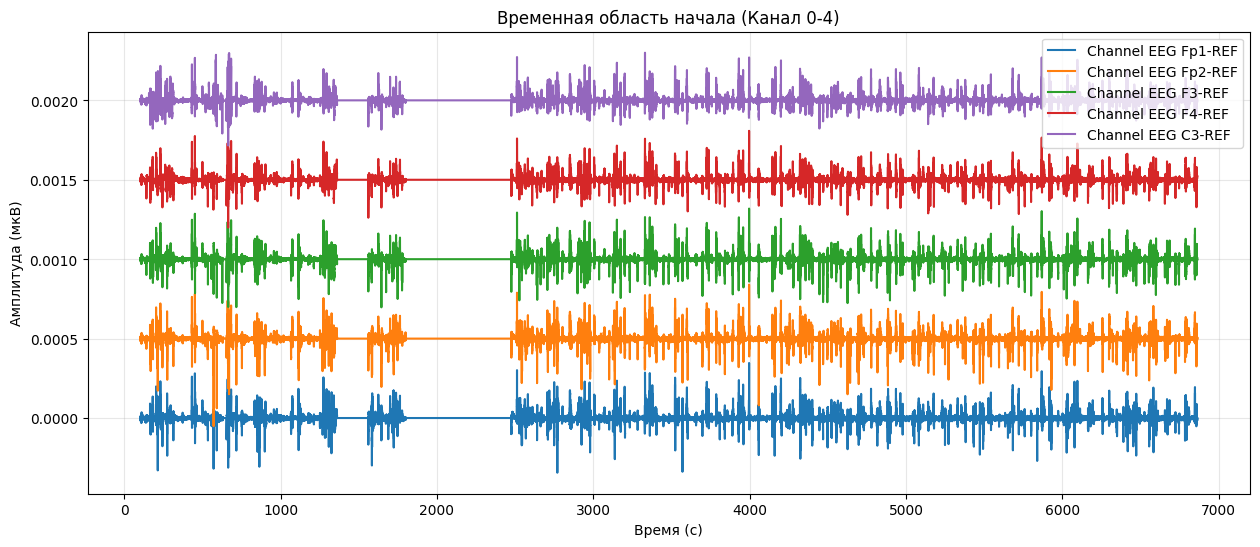

In [20]:
start_sample = int(start_sec * sfreq)
stop_sample = int(end_sec * sfreq)

# Данные во время атаки
data_seizure, times_seizure = raw[:, start_sample:stop_sample]

# Формы сигналов первых 5 каналов
plt.figure(figsize=(15, 6))
channels_to_show = min(5, data_seizure.shape[0])
for i in range(channels_to_show):
    # Ручная регулировка амплитуды и смещения.
    plt.plot(times_seizure, data_seizure[i] + i * 500e-6, label=f'Channel {raw.ch_names[i]}')

plt.title(f"Временная область начала (Канал 0-{channels_to_show-1})")
plt.xlabel("Bремя (с)")
plt.ylabel("Амплитуда (мкВ)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

**Результат：**

Эта часть кода извлекает временной сегмент приступа из непрерывного сигнала ЭЭГ и отображает временные характеристики первых 5 каналов.

Временные диаграммы показывают резкие изменения электрофизиологической активности во время приступа. По сравнению с периодом покоя, диаграммы во время приступа демонстрируют высокую амплитуду и высокую синхронность.

## 3. Обработка усреднения сигнала

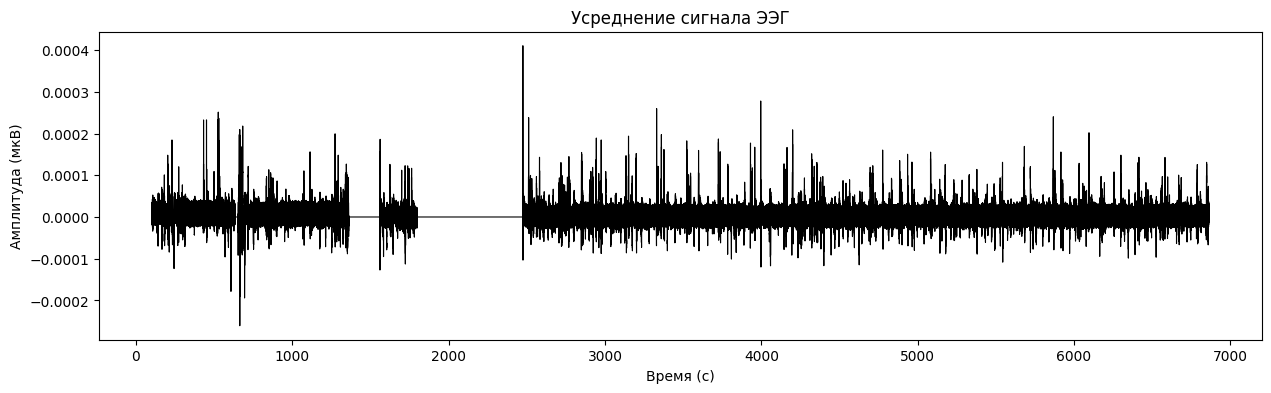

In [22]:
# усреднение сигнала
# avg = (ch1 + ch2 + ... + chN) / N
avg_signal = np.mean(data_seizure, axis=0)

plt.figure(figsize=(15, 4))
plt.plot(times_seizure, avg_signal, color='black', linewidth=0.8)
plt.title("Усреднение сигнала ЭЭГ")
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда (мкВ)")
plt.show()

**Анализ：** 

Усреднение эффективно выделяет общие характеристики мозговой активности по всему мозгу и подавляет потенциальные локальные артефакты в отдельных каналах. Этот усредненный сигнал может служить репрезентативным представлением всей эпилептической активности./

## 4. Частотная фильтрация (фильтр нижних частот 60 Гц)

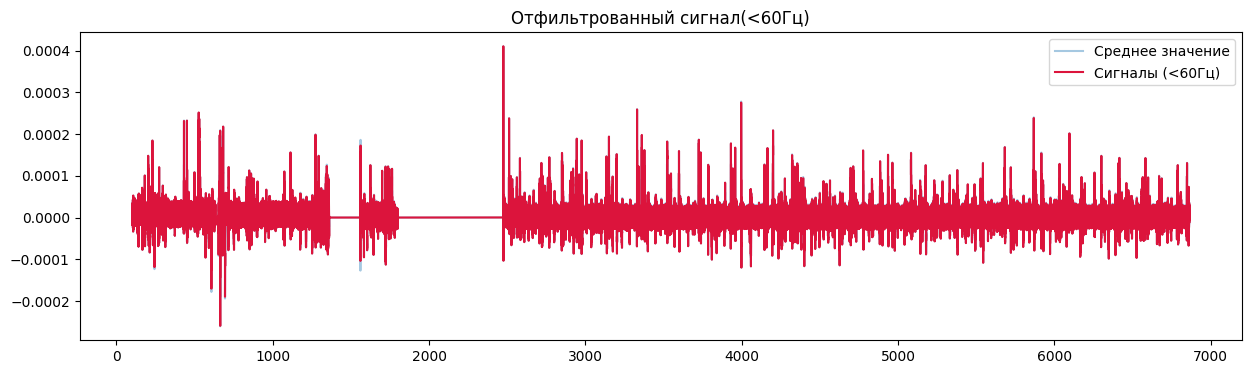

In [23]:
# Использование FIR-фильтра
filtered_signal = mne.filter.filter_data(avg_signal, sfreq, l_freq=None, h_freq=60.0, verbose=False)

plt.figure(figsize=(15, 4))
plt.plot(times_seizure, avg_signal, label='Среднее значение', alpha=0.4)
plt.plot(times_seizure, filtered_signal, label='Сигналы (<60Гц)', color='crimson')
plt.title("Отфильтрованный сигнал(<60Гц)")
plt.legend()
plt.show()

## 5. Спектрограмма и вейвлет-преобразование сигнала

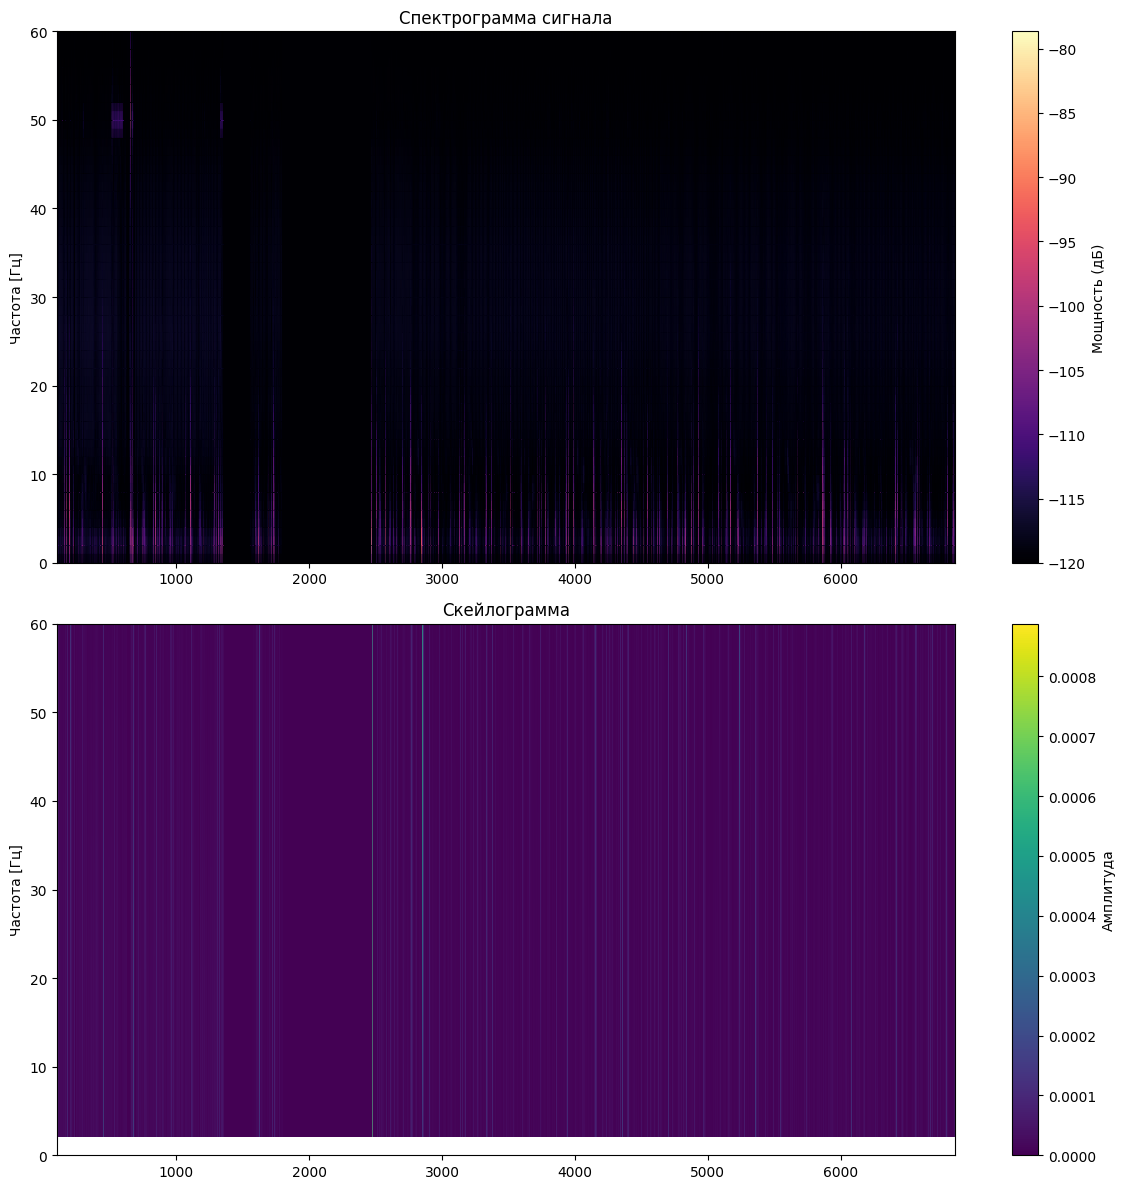

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# (1) Спектрограмма сигнала(STFT)
f, t_spec, Sxx = signal.spectrogram(filtered_signal, sfreq, nperseg=int(sfreq/2))
im1 = ax1.pcolormesh(t_spec + start_sec, f, 10 * np.log10(Sxx + 1e-12), shading='gouraud', cmap='magma')
ax1.set_title('Спектрограмма сигнала')
ax1.set_ylabel('Частота [Гц]')
ax1.set_ylim(0, 60)
fig.colorbar(im1, ax=ax1, label='Мощность (дБ)')

# (2) вейвлет-преобразование сигнала
# Morlet
widths = np.arange(1, 100)
cwtmatr, freqs = pywt.cwt(filtered_signal, widths, 'morl', sampling_period=1/sfreq)

# Параметры скорректированы в соответствии с временными рамками.
im2 = ax2.imshow(np.abs(cwtmatr), extent=[start_sec, end_sec, freqs[-1], freqs[0]], 
                 aspect='auto', interpolation='bilinear', cmap='viridis')
ax2.set_title('Скейлограмма')
ax2.set_ylabel('Частота [Гц]')
ax2.set_ylim(0, 60)
fig.colorbar(im2, ax=ax2, label='Амплитуда')

plt.tight_layout()
plt.show()

**Анализ：** 

* **Анализ спектрограммы**：динамика спектральной плотности мощности. Спектрограммы, основанные на кратковременном преобразовании Фурье (STFT), количественно демонстрируют эволюцию энергии сигнала вдоль частотной оси; в интервале всплесков энергия проявляет устойчивые всплески интенсивности в определенном частотном диапазоне (обычно 3-15 Гц).
* **Анализ скейлограммы**: многомасштабные нестационарные характеристики.Из-за значительной нестационарности сигналов ЭЭГ традиционное преобразование Фурье имеет ограничения по частотно-временному разрешению. Вейвлет-преобразование с использованием вейвлетов Морле в качестве базисных функций обеспечивает превосходные возможности динамического анализа. Вейвлет-спектры выявляют мгновенные характеристики дрейфа частоты эпилептических припадков, наблюдая динамический процесс постепенного изменения частоты разряда от быстрых колебаний в начале припадка до более медленных волн.

**Заключение：** 

Этот код, посредством предварительной обработки и многомерного извлечения признаков из исходных данных eeg1.edf, подтверждает ключевую ценность частотно-временного анализа в анализе ЭЭГ-сигналов. В эксперименте были оптимизированы пространственные признаки и решена проблема узкого места в вычислительной памяти при больших объемах данных с помощью понижения частоты дискретизации и усреднения; низкочастотная фильтрация (<60 Гц) устранила помехи от окружающего шума; и, наконец, путем объединения спектрограмм (STFT) и вейвлет-преобразований (CWT) он не только количественно оценил значительные всплески энергии в определенных частотных диапазонах во время приступов, но и более точно зафиксировал мгновенные характеристики сдвига частоты приступа, переходящих от высоких частот к медленным волнам.